# Tenerife Weekly Audit + EDA (TFE)

**Project:** Climate–Mortality (Diciembre25)

**Goal:** Produce a reproducible, weekly-level exploratory analysis for Tenerife, focusing on (1) data quality/coverage, (2) temperature (absolute vs anomaly), and (3) calima intensity signals, while being explicit about limitations.

**Saved outputs:** QA tables and key descriptive tables (CSV) under `reports/tfe/`.


## 0. Setup
Imports, path setup, and shared helper utilities.


In [23]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ISLAND_NAME = "tenerife"
ISLAND_CODE = "tfe"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

# --- shared notebook helpers ---
from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary, set_island_paths,
    autosave_fig, save_table,
)

# --- reports output paths ---
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# --- data input ---
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2015_2024.parquet"
print("FP:", FP)

assert FP.exists(), f"Missing file: {FP}"


CWD : C:\dev\projects\climate_mortality\islands\tenerife
ROOT: C:\dev\projects\climate_mortality
src exists?: True
FIG_DIR: C:\dev\projects\climate_mortality\reports\islands\figures\tenerife
TAB_DIR: C:\dev\projects\climate_mortality\reports\islands\tables\tenerife
FP: C:\dev\projects\climate_mortality\data\processed\tenerife\master\master_tfe_2015_2024.parquet


## 1. Load data
Load the island master dataset and subset to Tenerife (`island_code == 'tfe'`).


In [3]:
# C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\master\master_tfe_2015_2024.parquet

print("ROOT:", ROOT)
print("FP:", FP)
assert FP.exists(), f"No existe: {FP}"

section("EDA core weekly Tenerife")

df = pd.read_parquet(FP)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

glance(df, label="eda_core_weekly_tfe", n=5)

checks(df,
       required=["week_start","deaths_week"],
       key=["week_start"],
       dt="week_start")

num_summary(df)

ROOT: C:\dev\projects\climate_mortality
FP: C:\dev\projects\climate_mortality\data\processed\tenerife\master\master_tfe_2015_2024.parquet

EDA core weekly Tenerife

--- eda_core_weekly_tfe ---
shape: (471, 35)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
temp_c_mean                           float64
tmax_c_mean                           float64
tmin_c_mean                           float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
low_vis_confirmed_days_week             int64
low_vis_confirmed_any_week              int64
low_vis_possible_days_week              int64
low_vis_possible_any_week               int64
low_vis_any_days_week                   int64
low_vis_any_week                        int6

,week_start,year,island,island_code,deaths_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,pressure_hpa_mean,...,NO2,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag
0,2015-12-28,2015,tenerife,tfe,129.0,19.300000,23.966667,14.666667,67.333333,1016.700000,...,74.333333,54.000000,3,0,NaN,NaN,NaN,NaN,NaN,blue
1,2016-01-04,2016,tenerife,tfe,132.0,19.100000,23.342857,14.828571,65.428571,1013.242857,...,72.857143,56.571429,7,0,NaN,NaN,NaN,NaN,NaN,blue
2,2016-01-11,2016,tenerife,tfe,162.0,21.642857,26.042857,17.242857,57.571429,1011.921429,...,87.857143,46.571429,7,0,NaN,NaN,NaN,NaN,NaN,blue
3,2016-01-18,2016,tenerife,tfe,153.0,20.100000,24.071429,16.157143,63.285714,1014.792857,...,77.714286,60.285714,7,0,NaN,NaN,NaN,NaN,NaN,blue
4,2016-01-25,2016,tenerife,tfe,117.0,20.628571,24.671429,16.614286,53.571429,1018.814286,...,88.000000,65.142857,7,0,NaN,NaN,NaN,NaN,NaN,blue


,count,mean,std,min,25%,50%,75%,max
year,471.0,2019.993631,2.594996,2015.000000,2018.000000,2020.000000,2022.000000,2024.000000
deaths_week,471.0,138.641189,21.618765,92.000000,123.000000,137.000000,151.000000,214.000000
temp_c_mean,471.0,22.104412,2.652379,16.985714,19.942857,21.942857,24.300000,30.971429
tmax_c_mean,471.0,26.019886,2.834794,20.400000,23.692857,25.757143,28.114286,36.942857
tmin_c_mean,471.0,18.186941,2.572821,12.728571,16.100000,18.142857,20.400000,24.985714
humidity_mean,471.0,61.457709,6.945367,27.714286,58.714286,62.428571,65.773810,77.714286
pressure_hpa_mean,471.0,1009.721078,2.978178,1000.542857,1007.650000,1009.192857,1011.282143,1018.814286
wind_ms_mean,471.0,6.242013,1.527180,3.057143,5.036905,6.228571,7.364286,10.942857
low_vis_confirmed_days_week,471.0,0.377919,0.781066,0.000000,0.000000,0.000000,0.000000,5.000000
low_vis_confirmed_any_week,471.0,0.246285,0.431304,0.000000,0.000000,0.000000,0.000000,1.000000


In [4]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
elif "tmax_anom_mean" in df.columns:
    print("tmax_anom_mean already present.")
else:
    print("Missing base column tmax_c_mean.")

corr_tmax_anom = df[["deaths_week", "tmax_anom_mean"]].dropna().corr().iloc[0, 1]
print("Corr Tmax_anom:",corr_tmax_anom)

Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Corr Tmax_anom: 0.06447637769829928


In [5]:
# --- derive only missing anomaly columns actually needed ---

if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")


Created excess_deaths from deaths_week using month-of-year mean.


In [6]:
# Ensure weekly datetime
df['week_start'] = pd.to_datetime(df['week_start'], errors='coerce')

# Subset to Tenerife if needed
if 'island_code' in df.columns:
    df = df.loc[df['island_code'].eq('tfe')].copy()

df = df.sort_values('week_start').reset_index(drop=True)
glance(df, label='tfe_master_weekly', n=5)

# Merge calima proxy weekly dataset (kept external to the base master)
calima_fp = ROOT / 'data' / 'processed' / 'tenerife' / 'calima' / 'calima_proxy_weekly_tfe_2015_2024_v2.parquet'
print('Calima proxy FP:', calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima['week_start'] = pd.to_datetime(calima['week_start'], errors='coerce')

    keep = [
        'week_start',
        'calima_proxy_score_v2',
        'calima_proxy_level_v2',
    ]
    extra_keep = [c for c in [
        'cap_dust_yellow_plus_week',
        'cap_dust_level_max_week',
        'calima_dai_flag',
    ] if c in calima.columns]

    calima_keep = [c for c in keep + extra_keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != 'week_start' and c in df.columns]
    if overlap:
        print('Dropping overlapping columns before merge:', overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on='week_start', how='left')
    print('Merged calima proxy columns:', [c for c in calima_keep if c != 'week_start'])
else:
    print('Calima proxy weekly dataset not found. Section 6.1 will be skipped.')

print(df.shape)



--- tfe_master_weekly ---
shape: (471, 38)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
temp_c_mean                           float64
tmax_c_mean                           float64
tmin_c_mean                           float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
low_vis_confirmed_days_week             int64
low_vis_confirmed_any_week              int64
low_vis_possible_days_week              int64
low_vis_possible_any_week               int64
low_vis_any_days_week                   int64
low_vis_any_week                        int64
confirmed_airports_max_week             int64
possible_airports_max_week              int64
airports_obs_max_week                   int64
vis_min_m_week            

,week_start,year,island,island_code,deaths_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,pressure_hpa_mean,...,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,month,tmax_anom_mean,excess_deaths
0,2015-12-28,2015,tenerife,tfe,129.0,19.300000,23.966667,14.666667,67.333333,1016.700000,...,0,NaN,NaN,NaN,NaN,NaN,blue,12,0.323393,-19.225000
1,2016-01-04,2016,tenerife,tfe,132.0,19.100000,23.342857,14.828571,65.428571,1013.242857,...,0,NaN,NaN,NaN,NaN,NaN,blue,1,0.270093,-34.463415
2,2016-01-11,2016,tenerife,tfe,162.0,21.642857,26.042857,17.242857,57.571429,1011.921429,...,0,NaN,NaN,NaN,NaN,NaN,blue,1,2.970093,-4.463415
3,2016-01-18,2016,tenerife,tfe,153.0,20.100000,24.071429,16.157143,63.285714,1014.792857,...,0,NaN,NaN,NaN,NaN,NaN,blue,1,0.998664,-13.463415
4,2016-01-25,2016,tenerife,tfe,117.0,20.628571,24.671429,16.614286,53.571429,1018.814286,...,0,NaN,NaN,NaN,NaN,NaN,blue,1,1.598664,-49.463415


Calima proxy FP: C:\dev\projects\climate_mortality\data\processed\tenerife\calima\calima_proxy_weekly_tfe_2015_2024_v2.parquet
Dropping overlapping columns before merge: ['cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']
Merged calima proxy columns: ['calima_proxy_score_v2', 'calima_proxy_level_v2', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']
(471, 40)


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.


In [7]:
qa = checks(df, required=['week_start','deaths_week'], key=['week_start'], dt='week_start')
display(qa)

miss = missing_table(df)
display(miss.head(25))


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=647
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
cap_dust_yellow_plus_week,129,0.2739
cap_coverage_week,129,0.2739
cap_heat_level_max_week,129,0.2739
cap_heat_yellow_plus_week,129,0.2739
cap_dust_level_max_week,129,0.2739
NO2,1,0.0021
O3,1,0.0021
week_start,0,0.0000
tmin_c_mean,0,0.0000
tmax_c_mean,0,0.0000


In [8]:
# Save QA tables
save_table(qa.reset_index(), TAB_DIR, 'tfe_qa_checks.csv', index=False)
save_table(miss.head(50), TAB_DIR, 'tfe_missing_top50.csv')

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\tfe_qa_checks.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\tfe_missing_top50.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/tenerife/tfe_missing_top50.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).


## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.


In [9]:
core_cols = [
    'deaths_week',
    'temp_c_mean','tmax_c_mean','tmin_c_mean',
    'humidity_mean','pressure_hpa_mean','wind_ms_mean',
    'PM10','PM2.5','SO2','NO2','O3',
    'cap_heat_level_max_week','cap_dust_level_max_week',
    'cap_heat_yellow_plus_week','cap_dust_yellow_plus_week',
    'cap_coverage_week','calima_dai_flag',
    'low_vis_any_week','vis_min_m_week','rh_min_pct_week'
]
desc = num_summary(df, cols=core_cols)
display(desc)


,count,mean,std,min,25%,50%,75%,max
deaths_week,471.0,138.641189,21.618765,92.000000,123.000000,137.000000,151.000000,214.000000
temp_c_mean,471.0,22.104412,2.652379,16.985714,19.942857,21.942857,24.300000,30.971429
tmax_c_mean,471.0,26.019886,2.834794,20.400000,23.692857,25.757143,28.114286,36.942857
tmin_c_mean,471.0,18.186941,2.572821,12.728571,16.100000,18.142857,20.400000,24.985714
humidity_mean,471.0,61.457709,6.945367,27.714286,58.714286,62.428571,65.773810,77.714286
pressure_hpa_mean,471.0,1009.721078,2.978178,1000.542857,1007.650000,1009.192857,1011.282143,1018.814286
wind_ms_mean,471.0,6.242013,1.527180,3.057143,5.036905,6.228571,7.364286,10.942857
PM10,471.0,52.289340,57.905025,6.285714,24.785714,36.428571,54.500000,580.142857
PM2.5,471.0,15.933040,12.794183,3.428571,8.857143,12.571429,17.857143,132.714286
SO2,471.0,7.647659,4.875600,2.000000,4.142857,6.571429,10.214286,39.571429


In [10]:
desc.to_csv(TAB_DIR / 'desc_core_tfe.csv')
print('Saved:', TAB_DIR / 'desc_core_tfe.csv')


Saved: C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\desc_core_tfe.csv


## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_weekly_deaths_timeseries.png


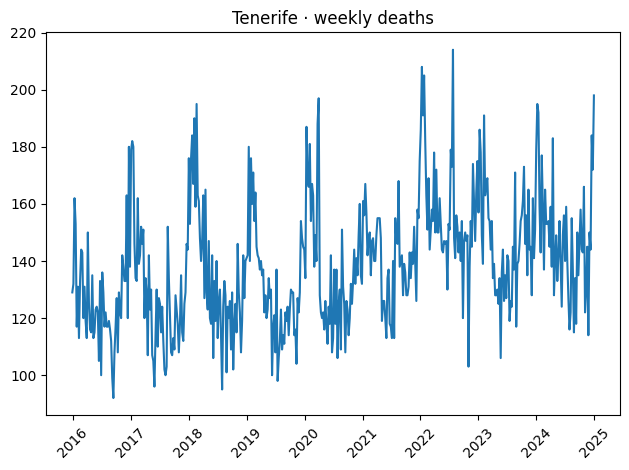

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_weekly_tmax_timeseries.png


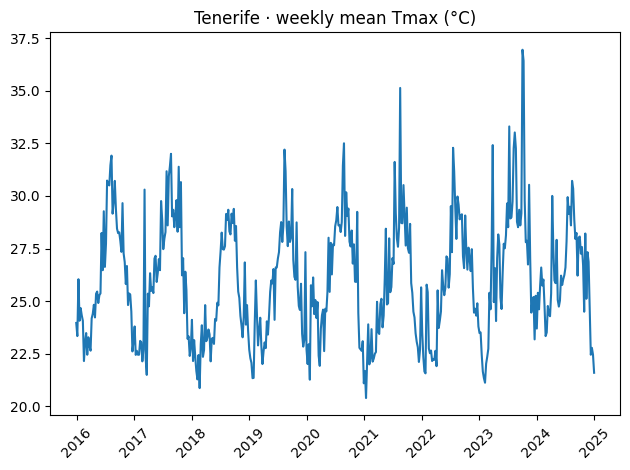

In [11]:
plt.figure()
plt.plot(df['week_start'], df['deaths_week'])
plt.title('Tenerife · weekly deaths')
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(FIG_DIR / 'tfe_eda01_weekly_deaths_timeseries.png')
plt.show()

plt.figure()
plt.plot(df['week_start'], df['tmax_c_mean'])
plt.title('Tenerife · weekly mean Tmax (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(FIG_DIR / 'tfe_eda01_weekly_tmax_timeseries.png')
plt.show()


## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_deaths_vs_absolute_tmax_scatter.png


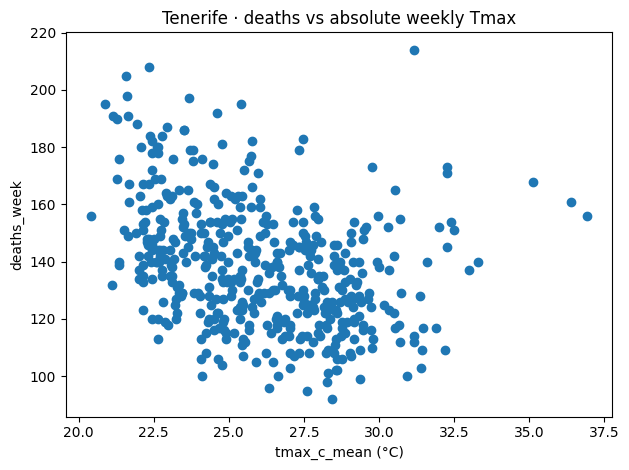

corr(deaths, tmax_c_mean): -0.3437


In [12]:
plt.figure()
plt.scatter(df['tmax_c_mean'], df['deaths_week'])
plt.xlabel('tmax_c_mean (°C)')
plt.ylabel('deaths_week')
plt.title('Tenerife · deaths vs absolute weekly Tmax')
plt.tight_layout()
autosave_fig(FIG_DIR / 'tfe_eda01_deaths_vs_absolute_tmax_scatter.png')
plt.show()

corr_abs = df[['deaths_week','tmax_c_mean']].corr().iloc[0,1]
print('corr(deaths, tmax_c_mean):', round(float(corr_abs), 4))


##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_deaths_vs_temperature_anomaly_scatter.png


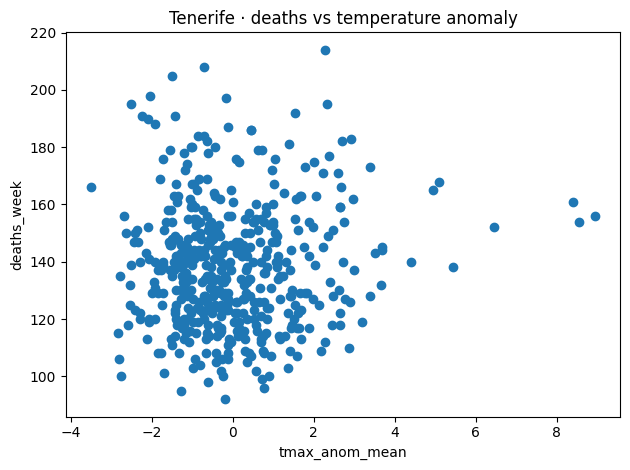

corr(deaths, tmax_anom_mean): 0.0645


In [13]:
anom_col = None
for c in ['tmax_anom_mean_week','tmax_anom_mean','tmax_anom_c_mean','tmax_anom']:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print('No anomaly column found in this master. (Skip or create anomalies upstream.)')
else:
    plt.figure()
    plt.scatter(df[anom_col], df['deaths_week'])
    plt.xlabel(anom_col)
    plt.ylabel('deaths_week')
    plt.title('Tenerife · deaths vs temperature anomaly')
    plt.tight_layout()
    autosave_fig(FIG_DIR / 'tfe_eda01_deaths_vs_temperature_anomaly_scatter.png')
    plt.show()
    corr_anom = df[['deaths_week', anom_col]].corr().iloc[0,1]
    print(f'corr(deaths, {anom_col}):', round(float(corr_anom), 4))


### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.


In [14]:
# --- official heat flags for this notebook ---
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Official heat thresholds from tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

Official heat thresholds from tmax_c_mean -> p90=29.47, p95=30.71
heat_p95
0    446
1     25
Name: count, dtype: int64


In [15]:
tmp = df.copy()

tab_p95 = tmp.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))


,count,mean,median
heat_p95,,,
0,446,138.639013,137.0
1,25,138.680000,140.0


Δ deaths (heat_p95 vs baseline): 0.04


In [16]:
save_table(tab_p95.reset_index(), TAB_DIR, "heat_p95_deaths_tfe.csv", index=False)

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\heat_p95_deaths_tfe.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/tenerife/heat_p95_deaths_tfe.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.


,missing,missing_pct
calima_proxy_score_v2,0,0.0
calima_proxy_level_v2,0,0.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_audit_missing_tfe.csv


,calima_proxy_level_v2,weeks
0,no_calima,276
1,possible,125
2,intense,39
3,probable,31


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_level_counts_tfe.csv
Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\tenerife\tfe_eda01_calima_proxy_level_distribution.png


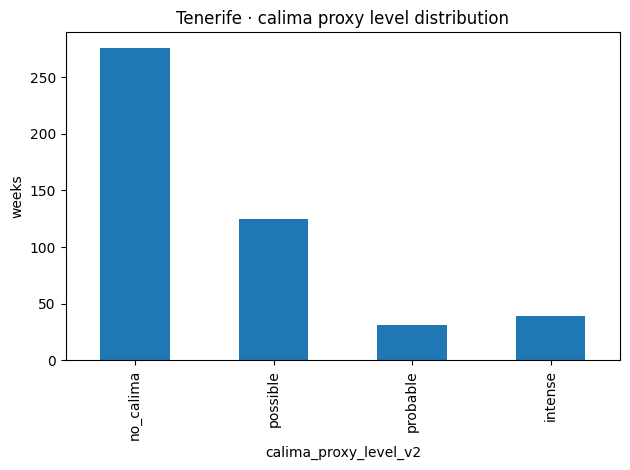

cap_dust_yellow_plus_week,0.0,1.0,NaN
calima_proxy_level_v2,,,
intense,23,13,3
no_calima,199,0,77
possible,83,4,38
probable,18,2,11


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_vs_cap_yellow_tfe.csv
Alignment: 0.7894736842105263


calima_dai_flag,blue,green,red,yellow
calima_proxy_level_v2,,,,
intense,7,2,12,4
no_calima,184,2,2,2
possible,76,8,3,5
probable,12,4,2,2


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_vs_dai_valid_tfe.csv


In [17]:
proxy_cols = ['calima_proxy_score_v2', 'calima_proxy_level_v2']
have_proxy = all(c in df.columns for c in proxy_cols)

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename('missing').to_frame()
    proxy_na['missing_pct'] = (proxy_na['missing'] / len(df)).round(4)
    display(proxy_na)
    save_table(proxy_na.reset_index().rename(columns={'index': 'column'}), TAB_DIR , 'calima_proxy_audit_missing_tfe.csv', index=False)

    proxy_counts = (
        df['calima_proxy_level_v2']
        .value_counts(dropna=False)
        .rename_axis('calima_proxy_level_v2')
        .reset_index(name='weeks')
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, 'calima_proxy_level_counts_tfe.csv', index=False)

    plot_counts = df['calima_proxy_level_v2'].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ['no_calima', 'possible', 'probable', 'intense']
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index]).dropna()

        plt.figure()
        plot_counts.plot(kind='bar')
        plt.ylabel('weeks')
        plt.title('Tenerife · calima proxy level distribution')
        plt.tight_layout()
        autosave_fig(FIG_DIR / 'tfe_eda01_calima_proxy_level_distribution.png')
        plt.show()

    if 'cap_dust_yellow_plus_week' in df.columns:
        cap_xtab = pd.crosstab(df['calima_proxy_level_v2'], df['cap_dust_yellow_plus_week'], dropna=False)
        display(cap_xtab)
        save_table(cap_xtab, TAB_DIR, 'calima_proxy_vs_cap_yellow_tfe.csv',index=False)
        tmp = df.copy()
        tmp["proxy_ge_probable"] = tmp["calima_proxy_level_v2"].isin(["probable", "intense"])
        
        cap_yellow = tmp["cap_dust_yellow_plus_week"] == 1
        alignment = tmp.loc[cap_yellow, "proxy_ge_probable"].mean()
        
        print("Alignment:",alignment)

    if 'calima_dai_flag' in df.columns:
        dai_valid = df['week_start'] <= pd.Timestamp('2022-03-31')
        dai_xtab = pd.crosstab(
            df.loc[dai_valid, 'calima_proxy_level_v2'],
            df.loc[dai_valid, 'calima_dai_flag'],
            dropna=False
        )
        display(dai_xtab)
        save_table(dai_xtab, TAB_DIR, 'calima_proxy_vs_dai_valid_tfe.csv',index=False)
else:
    print('No calima proxy columns found after merge. Check the processed Tenerife calima dataset path and column names.')


### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).

In [18]:
if 'calima_proxy_level_v2' in df.columns:
    cal = df.groupby('calima_proxy_level_v2')['deaths_week'].agg(['count','mean','median']).sort_index()
    display(cal)
    save_table(cal, TAB_DIR, 'calima_proxy_level_v2_deaths_tfe.csv',index=False)
else:
    print('No calima_proxy_level_v2. Using calima_dai_flag if available...')
    if 'calima_dai_flag' in df.columns:
        cal = df.groupby('calima_dai_flag')['deaths_week'].agg(['count','mean','median']).sort_index()
        display(cal)
        save_table(cal, TAB_DIR,'calima_dai_flag_deaths_tfe.csv', index=False)


,count,mean,median
calima_proxy_level_v2,,,
intense,39,157.692308,158.0
no_calima,276,136.478261,135.0
possible,125,136.960000,134.0
probable,31,140.709677,140.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\calima_proxy_level_v2_deaths_tfe.csv


## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.


In [20]:
tmp = df.copy()

if "calima_proxy_level_v2" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level_v2"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

inter = tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"].agg(["count", "mean", "median"])
display(inter)

save_table(inter.reset_index(), TAB_DIR, "interaction_heat_p95_x_calima_intense_tfe.csv", index=False)


count        mean  median
heat_p95 calima_intense                           
0        0                 410  136.982927   135.0
         1                  36  157.500000   158.5
1        0                  22  135.772727   133.0
         1                   3  160.000000   156.0

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\tenerife\interaction_heat_p95_x_calima_intense_tfe.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/tenerife/interaction_heat_p95_x_calima_intense_tfe.csv')

### Key numbers to report
- Δ deaths (heat p95 vs baseline): **0.04**
- Δ deaths (calima intense vs baseline): **+20.52 deaths/week**
- Proxy coverage / missingness: **471/471 weeks covered, 0 missing (0.0%)**
- CAP yellow alignment with proxy: **79.0%**
- corr(deaths, tmax_c_mean): **-0.344**
- corr(deaths, Tmax anomaly): **0.064**

Intense calima weeks show higher mean deaths than the baseline group, while heat p95 weeks alone show almost no difference in mean deaths under this simple weekly threshold definition. The highest mean appears in weeks combining heat p95 and intense calima, but this cell contains only 3 weeks and should be interpreted cautiously.
